# 05 — Rotation and Parent-Mask Robustness

## Goal

This notebook evaluates the robustness of the models trained in Notebook 04.

No new model is trained.

We load the best checkpoints for:

1. Object Mask
2. Absolute XY
3. Relative UV

and evaluate them under controlled perturbations.

---

## Experiment A — Rotation Robustness

We jointly rotate:

- RGB image
- parent-object mask
- ground-truth part mask

Angles:

- 0°
- 15°
- 30°
- 45°
- 90°

Geometry is recomputed after rotation.

This tests whether the models rely on orientation-specific spatial priors.

---

## Experiment B — Parent-Mask Robustness

The RGB image and ground-truth part mask remain unchanged.

Only the parent-object mask is corrupted using:

- erosion
- dilation
- translation

Geometry is recomputed from the corrupted parent-object mask.

This simulates errors from an upstream object segmentation system.

---

## Main Questions

1. Does relative U/V degrade more strongly under rotation?
2. Does explicit geometry remain useful when the parent mask is imperfect?
3. Is relative U/V more sensitive to mask corruption than absolute X/Y?
4. Does DINOv2 reduce dependence on the explicit spatial priors?

No retraining or test-time adaptation is performed.

In [1]:
from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

import open_clip

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [3]:
from datasets import PascalPart116Dataset

print("PascalPart116Dataset imported successfully.")

PascalPart116Dataset imported successfully.


In [4]:
SEED = 42

IMAGE_SIZE = 224

BATCH_SIZE = 16
NUM_WORKERS = 4

VISUAL_DIM = 128
TEXT_DIM = 32

MASK_THRESHOLD = 0.5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "robustness"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

GEOMETRY_CHECKPOINT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "geometry"
)

print("Device:", DEVICE)
print("Robustness output:", OUTPUT_ROOT)
print("Checkpoint root:", GEOMETRY_CHECKPOINT_ROOT)

Device: cuda
Robustness output: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/robustness
Checkpoint root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/geometry


In [5]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print("Seed:", SEED)

Seed: 42


In [6]:
ROTATION_ANGLES = [
    0,
    15,
    30,
    45,
    90,
]


MASK_NOISE_CONDITIONS = [
    "clean",
    "erode_5",
    "erode_11",
    "dilate_5",
    "dilate_11",
    "shift_5",
    "shift_15",
]


MODEL_MODES = [
    "object_mask",
    "absolute_xy",
    "relative_uv",
]


print("Rotations:", ROTATION_ANGLES)

print(
    "Mask conditions:",
    MASK_NOISE_CONDITIONS,
)

Rotations: [0, 15, 30, 45, 90]
Mask conditions: ['clean', 'erode_5', 'erode_11', 'dilate_5', 'dilate_11', 'shift_5', 'shift_15']


In [7]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)

In [8]:
def get_resize_info(
    height,
    width,
    target_size=224,
):

    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(
        1,
        round(height * scale),
    )

    new_w = max(
        1,
        round(width * scale),
    )

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    top = pad_h // 2
    bottom = pad_h - top

    left = pad_w // 2
    right = pad_w - left

    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "scale": scale,
    }

In [9]:
def preprocess_image(
    image,
    target_size=224,
):

    image = image.float() / 255.0

    _, h, w = image.shape

    info = get_resize_info(
        h,
        w,
        target_size,
    )

    resized = TF.resize(
        image,
        [
            info["new_h"],
            info["new_w"],
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    display_image = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    normalized = (
        resized - IMAGENET_MEAN
    ) / IMAGENET_STD

    model_image = F.pad(
        normalized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    return (
        display_image,
        model_image,
        info,
    )

In [10]:
def preprocess_mask(
    mask,
    resize_info,
    preserve_positive=False,
):

    if mask.ndim == 2:
        mask = mask.unsqueeze(0)

    mask = mask.float()

    resized = TF.resize(
        mask,
        [
            resize_info["new_h"],
            resize_info["new_w"],
        ],
        interpolation=InterpolationMode.NEAREST,
    )

    if (
        preserve_positive
        and mask.sum() > 0
        and resized.sum() == 0
    ):

        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(
                resize_info["new_h"],
                resize_info["new_w"],
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return padded > 0.5

In [11]:
def prepare_clean_sample(
    raw_sample,
):

    (
        display_image,
        model_image,
        resize_info,
    ) = preprocess_image(
        raw_sample["image"],
        IMAGE_SIZE,
    )

    object_mask = preprocess_mask(
        raw_sample["object_mask"],
        resize_info,
        preserve_positive=True,
    )

    part_mask = preprocess_mask(
        raw_sample["part_mask"],
        resize_info,
        preserve_positive=True,
    )

    overlap = (
        object_mask
        & part_mask
    )

    if (
        part_mask.any()
        and not overlap.any()
    ):

        object_mask = (
            object_mask
            | part_mask
        )

    part_mask = (
        part_mask
        & object_mask
    )

    return {
        "display_image": display_image,
        "model_image": model_image,
        "object_mask": object_mask,
        "part_mask": part_mask,
    }

In [12]:
def rotate_sample(
    display_image,
    model_image,
    object_mask,
    part_mask,
    angle,
):

    rotated_display = TF.rotate(
        display_image,
        angle=angle,
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )

    rotated_model = TF.rotate(
        model_image,
        angle=angle,
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )

    rotated_object = TF.rotate(
        object_mask.float(),
        angle=angle,
        interpolation=InterpolationMode.NEAREST,
        fill=0.0,
    ) > 0.5

    rotated_part = TF.rotate(
        part_mask.float(),
        angle=angle,
        interpolation=InterpolationMode.NEAREST,
        fill=0.0,
    ) > 0.5

    return (
        rotated_display,
        rotated_model,
        rotated_object,
        rotated_part,
    )

In [13]:
raw_test = PascalPart116Dataset(
    split="test_unseen"
)

raw_sample = raw_test[0]

clean = prepare_clean_sample(
    raw_sample
)

angle = 45

(
    rotated_display,
    rotated_model,
    rotated_object,
    rotated_part,
) = rotate_sample(
    clean["display_image"],
    clean["model_image"],
    clean["object_mask"],
    clean["part_mask"],
    angle,
)

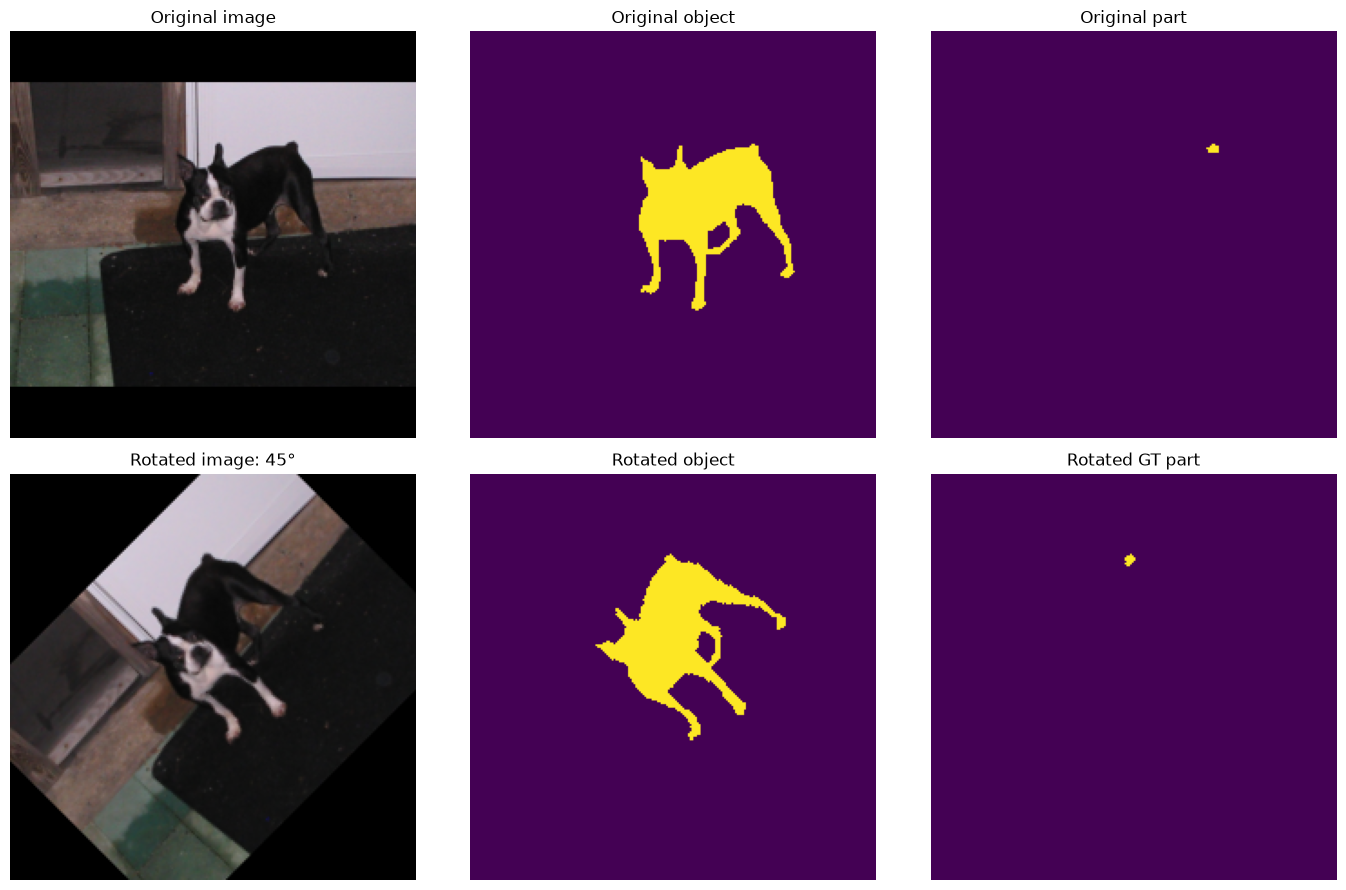

In [14]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 9),
)

axes[0, 0].imshow(
    clean["display_image"]
    .permute(1, 2, 0)
)

axes[0, 0].set_title(
    "Original image"
)

axes[0, 1].imshow(
    clean["object_mask"]
    .squeeze()
)

axes[0, 1].set_title(
    "Original object"
)

axes[0, 2].imshow(
    clean["part_mask"]
    .squeeze()
)

axes[0, 2].set_title(
    "Original part"
)

axes[1, 0].imshow(
    rotated_display
    .permute(1, 2, 0)
)

axes[1, 0].set_title(
    f"Rotated image: {angle}°"
)

axes[1, 1].imshow(
    rotated_object.squeeze()
)

axes[1, 1].set_title(
    "Rotated object"
)

axes[1, 2].imshow(
    rotated_part.squeeze()
)

axes[1, 2].set_title(
    "Rotated GT part"
)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
def dilate_mask(
    mask,
    kernel_size,
):

    assert (
        kernel_size % 2 == 1
    )

    x = (
        mask.float()
        .unsqueeze(0)
    )

    dilated = F.max_pool2d(
        x,
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size // 2,
    )

    return (
        dilated.squeeze(0)
        > 0.5
    )

In [16]:
def erode_mask(
    mask,
    kernel_size,
):

    assert (
        kernel_size % 2 == 1
    )

    x = (
        mask.float()
        .unsqueeze(0)
    )

    inverted = (
        1.0 - x
    )

    dilated_background = (
        F.max_pool2d(
            inverted,
            kernel_size=kernel_size,
            stride=1,
            padding=kernel_size // 2,
        )
    )

    eroded = (
        1.0
        - dilated_background
    )

    return (
        eroded.squeeze(0)
        > 0.5
    )

In [17]:
def shift_mask(
    mask,
    dx,
    dy,
):

    _, h, w = mask.shape

    output = torch.zeros_like(
        mask
    )

    src_x_start = max(
        0,
        -dx,
    )

    src_x_end = min(
        w,
        w - dx,
    )

    dst_x_start = max(
        0,
        dx,
    )

    dst_x_end = min(
        w,
        w + dx,
    )

    src_y_start = max(
        0,
        -dy,
    )

    src_y_end = min(
        h,
        h - dy,
    )

    dst_y_start = max(
        0,
        dy,
    )

    dst_y_end = min(
        h,
        h + dy,
    )

    if (
        src_x_start < src_x_end
        and src_y_start < src_y_end
    ):

        output[
            :,
            dst_y_start:dst_y_end,
            dst_x_start:dst_x_end,
        ] = mask[
            :,
            src_y_start:src_y_end,
            src_x_start:src_x_end,
        ]

    return output

In [18]:
SHIFT_DIRECTIONS = [
    (1, 0),
    (-1, 0),
    (0, 1),
    (0, -1),
    (1, 1),
    (-1, 1),
    (1, -1),
    (-1, -1),
]


def deterministic_shift(
    mask,
    magnitude,
    index,
):

    direction = SHIFT_DIRECTIONS[
        index
        % len(SHIFT_DIRECTIONS)
    ]

    dx = (
        direction[0]
        * magnitude
    )

    dy = (
        direction[1]
        * magnitude
    )

    return shift_mask(
        mask,
        dx=dx,
        dy=dy,
    )

In [19]:
def corrupt_object_mask(
    mask,
    condition,
    index,
):

    if condition == "clean":

        return mask.clone()


    if condition == "erode_5":

        return erode_mask(
            mask,
            kernel_size=5,
        )


    if condition == "erode_11":

        return erode_mask(
            mask,
            kernel_size=11,
        )


    if condition == "dilate_5":

        return dilate_mask(
            mask,
            kernel_size=5,
        )


    if condition == "dilate_11":

        return dilate_mask(
            mask,
            kernel_size=11,
        )


    if condition == "shift_5":

        return deterministic_shift(
            mask,
            magnitude=5,
            index=index,
        )


    if condition == "shift_15":

        return deterministic_shift(
            mask,
            magnitude=15,
            index=index,
        )


    raise ValueError(
        f"Unknown condition: {condition}"
    )

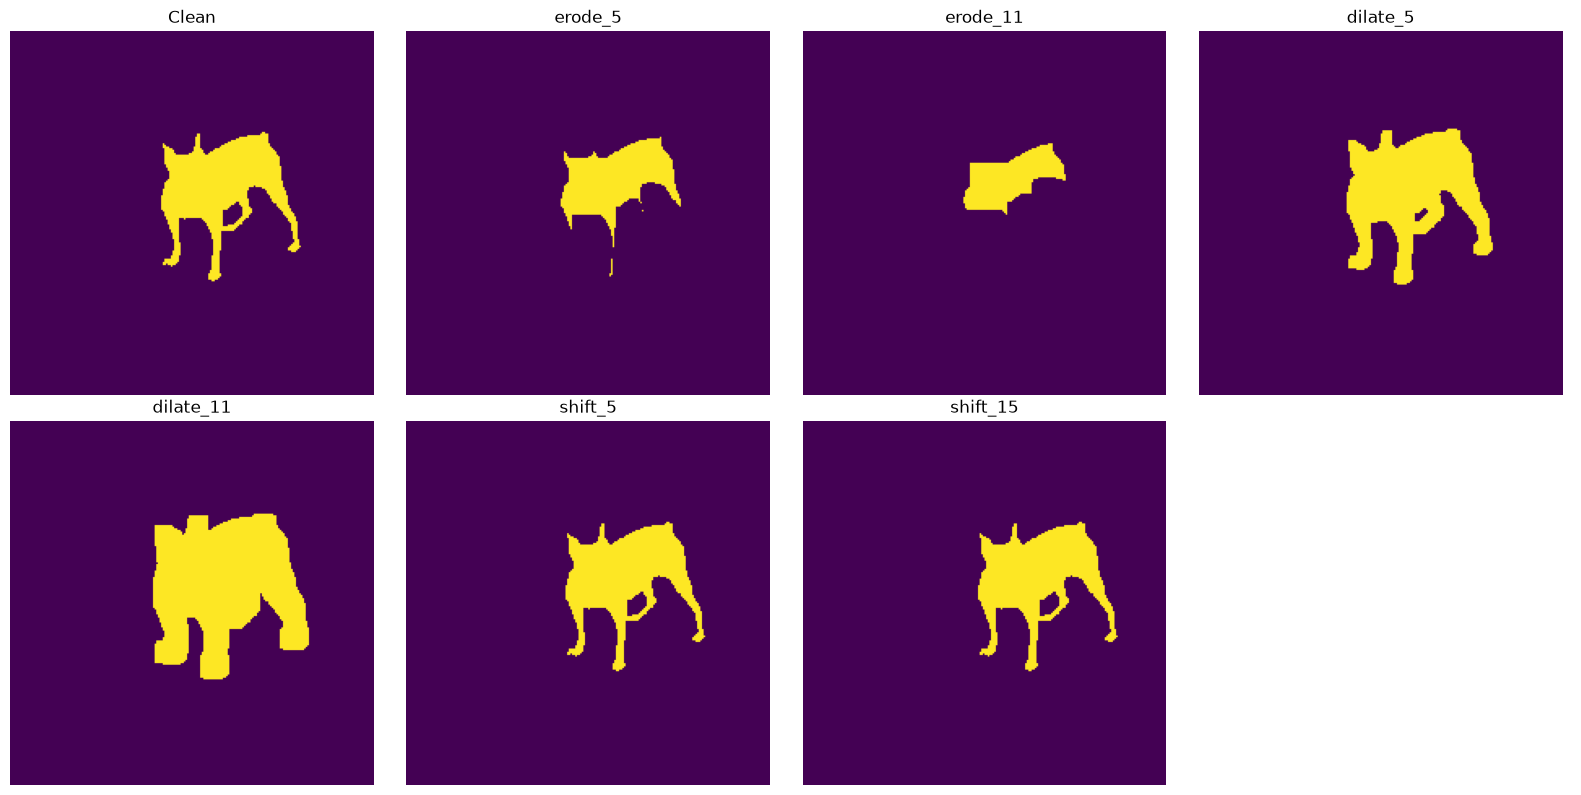

In [20]:
clean_mask = clean[
    "object_mask"
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

axes = axes.flatten()

axes[0].imshow(
    clean_mask.squeeze()
)

axes[0].set_title(
    "Clean"
)

for ax, condition in zip(
    axes[1:],
    MASK_NOISE_CONDITIONS[1:],
):

    corrupted = corrupt_object_mask(
        clean_mask,
        condition,
        index=0,
    )

    ax.imshow(
        corrupted.squeeze()
    )

    ax.set_title(
        condition
    )

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
def binary_mask_iou(
    mask_a,
    mask_b,
    eps=1e-6,
):

    a = mask_a.bool()
    b = mask_b.bool()

    intersection = (
        a & b
    ).sum().float()

    union = (
        a | b
    ).sum().float()

    return (
        intersection + eps
    ) / (
        union + eps
    )

In [22]:
for condition in (
    MASK_NOISE_CONDITIONS
):

    corrupted = corrupt_object_mask(
        clean_mask,
        condition,
        index=0,
    )

    score = binary_mask_iou(
        clean_mask,
        corrupted,
    )

    print(
        f"{condition:12s}",
        f"mask IoU = {score.item():.4f}"
    )

clean        mask IoU = 1.0000
erode_5      mask IoU = 0.6640
erode_11     mask IoU = 0.4148
dilate_5     mask IoU = 0.7334
dilate_11    mask IoU = 0.5305
shift_5      mask IoU = 0.5915
shift_15     mask IoU = 0.4045


In [23]:
def create_absolute_xy(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = (
            object_mask.squeeze(0)
        )
    else:
        mask = object_mask

    mask = mask.bool()

    h, w = mask.shape

    y = torch.linspace(
        0.0,
        1.0,
        h,
        dtype=torch.float32,
    )

    x = torch.linspace(
        0.0,
        1.0,
        w,
        dtype=torch.float32,
    )

    yy, xx = torch.meshgrid(
        y,
        x,
        indexing="ij",
    )

    mask_float = mask.float()

    return (
        (
            xx
            * mask_float
        ).unsqueeze(0),

        (
            yy
            * mask_float
        ).unsqueeze(0),
    )

In [24]:
def create_relative_uv(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = (
            object_mask.squeeze(0)
        )
    else:
        mask = object_mask

    mask = mask.bool()

    h, w = mask.shape

    u = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    v = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    ys, xs = torch.where(
        mask
    )

    if len(xs) == 0:

        return (
            u.unsqueeze(0),
            v.unsqueeze(0),
        )

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    x_denom = max(
        int(x_max - x_min),
        1,
    )

    y_denom = max(
        int(y_max - y_min),
        1,
    )

    u_values = (
        xs.float()
        - x_min.float()
    ) / x_denom

    v_values = (
        ys.float()
        - y_min.float()
    ) / y_denom

    u[
        ys,
        xs,
    ] = u_values

    v[
        ys,
        xs,
    ] = v_values

    return (
        u.unsqueeze(0),
        v.unsqueeze(0),
    )

## Critical Robustness Design

Coordinates are NOT transformed independently.

They are always recomputed from the parent-object mask that the model receives.

For example:

### Rotation

RGB rotates.

Parent mask rotates.

Part target rotates.

Then X/Y/U/V are recomputed.

---

### Mask Noise

RGB stays unchanged.

Ground-truth part mask stays unchanged.

Parent mask is corrupted.

Then X/Y/U/V are recomputed from the corrupted mask.

This is important because it simulates a real pipeline where geometry depends
on an upstream object-mask prediction.

In [25]:
class RobustnessDataset(Dataset):

    def __init__(
        self,
        split,
        experiment_type,
        condition,
    ):

        assert experiment_type in {
            "rotation",
            "mask_noise",
        }

        self.base_dataset = (
            PascalPart116Dataset(
                split=split
            )
        )

        self.experiment_type = (
            experiment_type
        )

        self.condition = (
            condition
        )

    def __len__(self):

        return len(
            self.base_dataset
        )

    def __getitem__(
        self,
        index,
    ):

        raw = (
            self.base_dataset[index]
        )

        clean = (
            prepare_clean_sample(
                raw
            )
        )

        display_image = (
            clean["display_image"]
        )

        model_image = (
            clean["model_image"]
        )

        clean_object_mask = (
            clean["object_mask"]
        )

        part_mask = (
            clean["part_mask"]
        )


        # --------------------------
        # Rotation experiment
        # --------------------------

        if (
            self.experiment_type
            == "rotation"
        ):

            angle = float(
                self.condition
            )

            (
                display_image,
                model_image,
                clean_object_mask,
                part_mask,
            ) = rotate_sample(
                display_image,
                model_image,
                clean_object_mask,
                part_mask,
                angle,
            )

            # No mask corruption.
            conditioning_mask = (
                clean_object_mask.clone()
            )


        # --------------------------
        # Mask noise experiment
        # --------------------------

        elif (
            self.experiment_type
            == "mask_noise"
        ):

            conditioning_mask = (
                corrupt_object_mask(
                    clean_object_mask,
                    self.condition,
                    index,
                )
            )


        # Geometry is based on the
        # mask actually given to model.

        (
            absolute_x,
            absolute_y,
        ) = create_absolute_xy(
            conditioning_mask
        )

        (
            relative_u,
            relative_v,
        ) = create_relative_uv(
            conditioning_mask
        )


        return {
            "sample_id": (
                raw["sample_id"]
            ),

            "image": (
                model_image
            ),

            "display_image": (
                display_image
            ),

            # Correct object mask after
            # any image-level transform.
            "clean_object_mask": (
                clean_object_mask.float()
            ),

            # Mask actually supplied to model.
            "object_mask": (
                conditioning_mask.float()
            ),

            # GT segmentation target.
            "part_mask": (
                part_mask.float()
            ),

            "absolute_x": (
                absolute_x
            ),

            "absolute_y": (
                absolute_y
            ),

            "relative_u": (
                relative_u
            ),

            "relative_v": (
                relative_v
            ),

            "query": (
                raw["query"]
            ),

            "object_name": (
                raw["object_name"]
            ),

            "part_name": (
                raw["part_name"]
            ),
        }

In [26]:
rotation_dataset = RobustnessDataset(
    split="test_unseen",
    experiment_type="rotation",
    condition=45,
)

sample = rotation_dataset[0]

for key in [
    "image",
    "clean_object_mask",
    "object_mask",
    "part_mask",
    "absolute_x",
    "absolute_y",
    "relative_u",
    "relative_v",
]:

    print(
        key,
        sample[key].shape,
    )

image torch.Size([3, 224, 224])
clean_object_mask torch.Size([1, 224, 224])
object_mask torch.Size([1, 224, 224])
part_mask torch.Size([1, 224, 224])
absolute_x torch.Size([1, 224, 224])
absolute_y torch.Size([1, 224, 224])
relative_u torch.Size([1, 224, 224])
relative_v torch.Size([1, 224, 224])


In [27]:
clean_dataset = RobustnessDataset(
    split="test_unseen",
    experiment_type="mask_noise",
    condition="clean",
)

eroded_dataset = RobustnessDataset(
    split="test_unseen",
    experiment_type="mask_noise",
    condition="erode_11",
)

clean_sample = clean_dataset[0]

eroded_sample = eroded_dataset[0]

print(
    "Image equal:",
    torch.allclose(
        clean_sample["image"],
        eroded_sample["image"],
    )
)

print(
    "Target equal:",
    torch.equal(
        clean_sample["part_mask"],
        eroded_sample["part_mask"],
    )
)

print(
    "Object mask equal:",
    torch.equal(
        clean_sample["object_mask"],
        eroded_sample["object_mask"],
    )
)

Image equal: True
Target equal: True
Object mask equal: False


In [28]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(
    DEVICE
)

dino.eval()

for p in dino.parameters():

    p.requires_grad = False

print(
    "DINOv2 loaded and frozen."
)

Using cache found in /home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded and frozen.


In [29]:
clip_model, _, _ = (
    open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai",
    )
)

clip_tokenizer = (
    open_clip.get_tokenizer(
        "ViT-B-32"
    )
)

clip_model = (
    clip_model
    .to(DEVICE)
)

clip_model.eval()

for p in clip_model.parameters():

    p.requires_grad = False

print(
    "CLIP loaded and frozen."
)

/home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded and frozen.


In [30]:
class TextEmbeddingCache:

    def __init__(
        self,
        model,
        tokenizer,
        device,
    ):

        self.model = model
        self.tokenizer = tokenizer
        self.device = device

        self.cache = {}

    @torch.no_grad()
    def _encode_missing(
        self,
        queries,
    ):

        missing = sorted(
            {
                q
                for q in queries
                if q not in self.cache
            }
        )

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = (
            self.tokenizer(
                prompts
            )
            .to(self.device)
        )

        embeddings = (
            self.model.encode_text(
                tokens
            )
        )

        embeddings = F.normalize(
            embeddings.float(),
            dim=-1,
        )

        for q, embedding in zip(
            missing,
            embeddings,
        ):

            self.cache[q] = (
                embedding.detach().cpu()
            )

    def __call__(
        self,
        queries,
    ):

        self._encode_missing(
            queries
        )

        result = torch.stack(
            [
                self.cache[q]
                for q in queries
            ]
        )

        return result.to(
            self.device,
            non_blocking=True,
        )

In [31]:
text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

In [32]:
class GeometryPartSegmenter(nn.Module):

    def __init__(
        self,
        dino_encoder,
        mode,
        visual_dim=128,
        text_dim=32,
    ):

        super().__init__()

        assert mode in {
            "object_mask",
            "absolute_xy",
            "relative_uv",
        }

        self.mode = mode

        self.dino = (
            dino_encoder
        )

        for p in self.dino.parameters():

            p.requires_grad = False


        self.visual_projection = (
            nn.Conv2d(
                384,
                visual_dim,
                kernel_size=1,
            )
        )


        self.text_projection = (
            nn.Sequential(

                nn.Linear(
                    512,
                    64,
                ),

                nn.GELU(),

                nn.Linear(
                    64,
                    text_dim,
                ),
            )
        )


        fusion_dim = (
            visual_dim
            + text_dim
            + 1
            + 2
        )


        self.decoder = nn.Sequential(

            nn.Conv2d(
                fusion_dim,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                128,
            ),

            nn.GELU(),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                64,
            ),

            nn.GELU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.GELU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=1,
            ),
        )


    def train(
        self,
        mode=True,
    ):

        super().train(mode)

        self.dino.eval()

        return self


    @torch.no_grad()
    def extract_dino_features(
        self,
        images,
    ):

        output = (
            self.dino.forward_features(
                images
            )
        )

        tokens = output[
            "x_norm_patchtokens"
        ]

        b, n, c = (
            tokens.shape
        )

        grid = int(
            n ** 0.5
        )

        return (
            tokens
            .transpose(1, 2)
            .reshape(
                b,
                c,
                grid,
                grid,
            )
        )


    def forward_from_features(
        self,
        dino_features,
        text_embeddings,
        object_mask,
        absolute_x,
        absolute_y,
        relative_u,
        relative_v,
        output_size,
    ):

        visual = (
            self.visual_projection(
                dino_features
            )
        )

        text = (
            self.text_projection(
                text_embeddings
            )
        )

        text_map = (
            text[:, :, None, None]
            .expand(
                -1,
                -1,
                visual.shape[-2],
                visual.shape[-1],
            )
        )

        spatial_size = (
            visual.shape[-2:]
        )


        mask_low = F.interpolate(
            object_mask,
            size=spatial_size,
            mode="nearest",
        )


        absolute_x_low = F.interpolate(
            absolute_x,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        absolute_y_low = F.interpolate(
            absolute_y,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        relative_u_low = F.interpolate(
            relative_u,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        relative_v_low = F.interpolate(
            relative_v,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )


        absolute_x_low *= mask_low
        absolute_y_low *= mask_low

        relative_u_low *= mask_low
        relative_v_low *= mask_low


        if self.mode == "object_mask":

            coord_1 = torch.zeros_like(
                mask_low
            )

            coord_2 = torch.zeros_like(
                mask_low
            )


        elif self.mode == "absolute_xy":

            coord_1 = absolute_x_low
            coord_2 = absolute_y_low


        elif self.mode == "relative_uv":

            coord_1 = relative_u_low
            coord_2 = relative_v_low


        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
                coord_1,
                coord_2,
            ],
            dim=1,
        )


        logits_low = (
            self.decoder(
                fused
            )
        )


        logits = F.interpolate(
            logits_low,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )

        return logits


    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
        absolute_x,
        absolute_y,
        relative_u,
        relative_v,
    ):

        features = (
            self.extract_dino_features(
                images
            )
        )

        return self.forward_from_features(
            features,
            text_embeddings,
            object_mask,
            absolute_x,
            absolute_y,
            relative_u,
            relative_v,
            images.shape[-2:],
        )

In [33]:
def load_trainable_state(
    model,
    checkpoint,
):

    model.visual_projection.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "visual_projection"
        ]
    )

    model.text_projection.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "text_projection"
        ]
    )

    model.decoder.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "decoder"
        ]
    )

In [34]:
def load_best_model(
    mode,
):

    checkpoint_path = (
        GEOMETRY_CHECKPOINT_ROOT
        / mode
        / "best.pt"
    )

    if not checkpoint_path.exists():

        raise FileNotFoundError(
            f"Missing checkpoint: "
            f"{checkpoint_path}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = (
        GeometryPartSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_dim=TEXT_DIM,
        )
        .to(DEVICE)
    )

    load_trainable_state(
        model,
        checkpoint,
    )

    model.eval()

    return model

In [35]:
models = {
    mode: load_best_model(
        mode
    )
    for mode in MODEL_MODES
}

print(
    "Loaded models:",
    list(models.keys())
)

Loaded models: ['object_mask', 'absolute_xy', 'relative_uv']


In [36]:
for name, model in models.items():

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(
        name,
        "trainable modules still present:",
        trainable,
    )

object_mask trainable modules still present: 364769
absolute_xy trainable modules still present: 364769
relative_uv trainable modules still present: 364769


In [37]:
for model in models.values():

    model.eval()

    for p in model.parameters():

        p.requires_grad = False

In [38]:
print(
    "All robustness models frozen."
)

All robustness models frozen.


In [39]:
@torch.no_grad()
def batch_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    union = (
        predictions
        | targets
    ).sum(
        dim=1
    ).float()

    return (
        intersection + eps
    ) / (
        union + eps
    )

In [40]:
@torch.no_grad()
def batch_dice(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    denominator = (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
    ).float()

    return (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

In [41]:
@torch.no_grad()
def batch_mask_iou(
    clean_mask,
    conditioning_mask,
    eps=1e-6,
):

    clean = (
        clean_mask >= 0.5
    ).flatten(1)

    corrupted = (
        conditioning_mask >= 0.5
    ).flatten(1)

    intersection = (
        clean
        & corrupted
    ).sum(
        dim=1
    ).float()

    union = (
        clean
        | corrupted
    ).sum(
        dim=1
    ).float()

    return (
        intersection + eps
    ) / (
        union + eps
    )

In [42]:
@torch.no_grad()
def evaluate_all_models(
    loader,
    models,
):

    totals = {
        name: {
            "iou": 0.0,
            "dice": 0.0,
        }
        for name in models
    }

    total_mask_iou = 0.0
    total_samples = 0

    shared_model = next(
        iter(
            models.values()
        )
    )

    for batch in loader:

        images = (
            batch["image"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        object_mask = (
            batch["object_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        clean_object_mask = (
            batch["clean_object_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        targets = (
            batch["part_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        absolute_x = (
            batch["absolute_x"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        absolute_y = (
            batch["absolute_y"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        relative_u = (
            batch["relative_u"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        relative_v = (
            batch["relative_v"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        text_embeddings = (
            text_encoder(
                batch["query"]
            )
        )

        batch_size = (
            images.shape[0]
        )


        # DINO only once.
        dino_features = (
            shared_model
            .extract_dino_features(
                images
            )
        )


        for name, model in (
            models.items()
        ):

            logits = (
                model
                .forward_from_features(
                    dino_features,
                    text_embeddings,
                    object_mask,
                    absolute_x,
                    absolute_y,
                    relative_u,
                    relative_v,
                    images.shape[-2:],
                )
            )

            ious = batch_iou(
                logits,
                targets,
                MASK_THRESHOLD,
            )

            dices = batch_dice(
                logits,
                targets,
                MASK_THRESHOLD,
            )

            totals[name]["iou"] += (
                ious.sum().item()
            )

            totals[name]["dice"] += (
                dices.sum().item()
            )


        mask_ious = batch_mask_iou(
            clean_object_mask,
            object_mask,
        )

        total_mask_iou += (
            mask_ious.sum().item()
        )

        total_samples += (
            batch_size
        )


    results = {}

    for name in models:

        results[name] = {
            "iou": (
                totals[name]["iou"]
                / total_samples
            ),

            "dice": (
                totals[name]["dice"]
                / total_samples
            ),
        }


    return (
        results,
        total_mask_iou
        / total_samples,
    )

In [43]:
smoke_dataset = RobustnessDataset(
    split="test_unseen",
    experiment_type="rotation",
    condition=45,
)

smoke_subset = Subset(
    smoke_dataset,
    range(
        min(
            64,
            len(smoke_dataset),
        )
    ),
)

smoke_loader = DataLoader(
    smoke_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

smoke_results, smoke_mask_iou = (
    evaluate_all_models(
        smoke_loader,
        models,
    )
)

print(
    smoke_results
)

print(
    "Mask IoU:",
    smoke_mask_iou
)

{'object_mask': {'iou': 0.21585774421691895, 'dice': 0.29748525470495224}, 'absolute_xy': {'iou': 0.22191202640533447, 'dice': 0.30894262343645096}, 'relative_uv': {'iou': 0.21091840416193008, 'dice': 0.2903054691851139}}
Mask IoU: 1.0


In [44]:
def evaluate_rotation_condition(
    split,
    angle,
):

    dataset = RobustnessDataset(
        split=split,
        experiment_type="rotation",
        condition=angle,
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )

    return evaluate_all_models(
        loader,
        models,
    )

In [45]:
rotation_rows = []

for angle in ROTATION_ANGLES:

    print(
        f"Seen | Rotation {angle}°"
    )

    results, mask_iou = (
        evaluate_rotation_condition(
            split="test_seen",
            angle=angle,
        )
    )

    for model_name, metrics in (
        results.items()
    ):

        rotation_rows.append(
            {
                "split": "seen",
                "angle": angle,
                "model": model_name,
                "iou": metrics["iou"],
                "dice": metrics["dice"],
                "conditioning_mask_iou": (
                    mask_iou
                ),
            }
        )

        print(
            f"  {model_name:12s} "
            f"IoU={metrics['iou']:.4f} "
            f"Dice={metrics['dice']:.4f}"
        )

Seen | Rotation 0°
  object_mask  IoU=0.3165 Dice=0.4173
  absolute_xy  IoU=0.3183 Dice=0.4168
  relative_uv  IoU=0.3160 Dice=0.4146
Seen | Rotation 15°
  object_mask  IoU=0.3046 Dice=0.4034
  absolute_xy  IoU=0.3073 Dice=0.4048
  relative_uv  IoU=0.3053 Dice=0.4027
Seen | Rotation 30°
  object_mask  IoU=0.2842 Dice=0.3784
  absolute_xy  IoU=0.2838 Dice=0.3752
  relative_uv  IoU=0.2849 Dice=0.3779
Seen | Rotation 45°
  object_mask  IoU=0.2518 Dice=0.3386
  absolute_xy  IoU=0.2522 Dice=0.3366
  relative_uv  IoU=0.2522 Dice=0.3373
Seen | Rotation 90°
  object_mask  IoU=0.1993 Dice=0.2730
  absolute_xy  IoU=0.2014 Dice=0.2745
  relative_uv  IoU=0.2045 Dice=0.2779


In [46]:
for angle in ROTATION_ANGLES:

    print(
        f"Unseen | Rotation {angle}°"
    )

    results, mask_iou = (
        evaluate_rotation_condition(
            split="test_unseen",
            angle=angle,
        )
    )

    for model_name, metrics in (
        results.items()
    ):

        rotation_rows.append(
            {
                "split": "unseen",
                "angle": angle,
                "model": model_name,
                "iou": metrics["iou"],
                "dice": metrics["dice"],
                "conditioning_mask_iou": (
                    mask_iou
                ),
            }
        )

        print(
            f"  {model_name:12s} "
            f"IoU={metrics['iou']:.4f} "
            f"Dice={metrics['dice']:.4f}"
        )

Unseen | Rotation 0°
  object_mask  IoU=0.2614 Dice=0.3544
  absolute_xy  IoU=0.2468 Dice=0.3392
  relative_uv  IoU=0.2652 Dice=0.3614
Unseen | Rotation 15°
  object_mask  IoU=0.2594 Dice=0.3526
  absolute_xy  IoU=0.2461 Dice=0.3384
  relative_uv  IoU=0.2612 Dice=0.3565
Unseen | Rotation 30°
  object_mask  IoU=0.2465 Dice=0.3363
  absolute_xy  IoU=0.2363 Dice=0.3254
  relative_uv  IoU=0.2504 Dice=0.3422
Unseen | Rotation 45°
  object_mask  IoU=0.2299 Dice=0.3161
  absolute_xy  IoU=0.2255 Dice=0.3111
  relative_uv  IoU=0.2346 Dice=0.3230
Unseen | Rotation 90°
  object_mask  IoU=0.1892 Dice=0.2650
  absolute_xy  IoU=0.1888 Dice=0.2636
  relative_uv  IoU=0.1948 Dice=0.2724


In [47]:
rotation_results = pd.DataFrame(
    rotation_rows
)

rotation_results

,split,angle,model,iou,dice,conditioning_mask_iou
0,seen,0,object_mask,0.316538,0.417286,1.0
1,seen,0,absolute_xy,0.318309,0.416804,1.0
2,seen,0,relative_uv,0.316015,0.414632,1.0
3,seen,15,object_mask,0.304563,0.403400,1.0
4,seen,15,absolute_xy,0.307286,0.404750,1.0
5,seen,15,relative_uv,0.305333,0.402715,1.0
6,seen,30,object_mask,0.284231,0.378432,1.0
7,seen,30,absolute_xy,0.283773,0.375231,1.0
8,seen,30,relative_uv,0.284902,0.377870,1.0
9,seen,45,object_mask,0.251825,0.338593,1.0


In [48]:
rotation_results[
    "iou_drop_from_zero"
] = 0.0


for split in [
    "seen",
    "unseen",
]:

    for model_name in (
        MODEL_MODES
    ):

        baseline = (
            rotation_results[
                (
                    rotation_results[
                        "split"
                    ]
                    == split
                )
                &
                (
                    rotation_results[
                        "model"
                    ]
                    == model_name
                )
                &
                (
                    rotation_results[
                        "angle"
                    ]
                    == 0
                )
            ][
                "iou"
            ]
            .iloc[0]
        )

        mask = (
            (
                rotation_results[
                    "split"
                ]
                == split
            )
            &
            (
                rotation_results[
                    "model"
                ]
                == model_name
            )
        )

        rotation_results.loc[
            mask,
            "iou_drop_from_zero",
        ] = (
            rotation_results.loc[
                mask,
                "iou",
            ]
            - baseline
        )


rotation_results

,split,angle,model,iou,dice,conditioning_mask_iou,iou_drop_from_zero
0,seen,0,object_mask,0.316538,0.417286,1.0,0.000000
1,seen,0,absolute_xy,0.318309,0.416804,1.0,0.000000
2,seen,0,relative_uv,0.316015,0.414632,1.0,0.000000
3,seen,15,object_mask,0.304563,0.403400,1.0,-0.011975
4,seen,15,absolute_xy,0.307286,0.404750,1.0,-0.011023
5,seen,15,relative_uv,0.305333,0.402715,1.0,-0.010682
6,seen,30,object_mask,0.284231,0.378432,1.0,-0.032307
7,seen,30,absolute_xy,0.283773,0.375231,1.0,-0.034536
8,seen,30,relative_uv,0.284902,0.377870,1.0,-0.031113
9,seen,45,object_mask,0.251825,0.338593,1.0,-0.064714


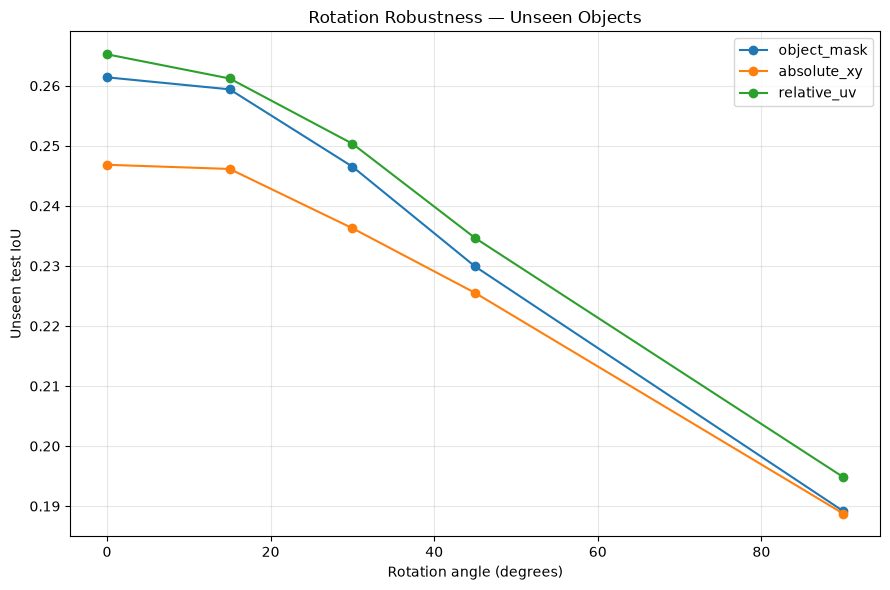

In [49]:
unseen_rotation = (
    rotation_results[
        rotation_results[
            "split"
        ]
        == "unseen"
    ]
)

plt.figure(
    figsize=(9, 6)
)

for model_name in MODEL_MODES:

    subset = unseen_rotation[
        unseen_rotation[
            "model"
        ]
        == model_name
    ]

    plt.plot(
        subset["angle"],
        subset["iou"],
        marker="o",
        label=model_name,
    )

plt.xlabel(
    "Rotation angle (degrees)"
)

plt.ylabel(
    "Unseen test IoU"
)

plt.title(
    "Rotation Robustness — Unseen Objects"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

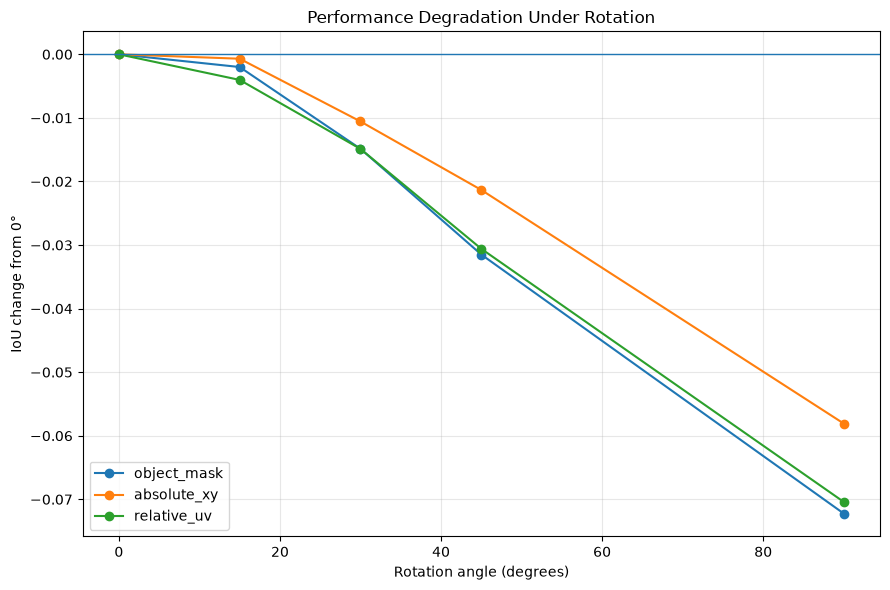

In [50]:
plt.figure(
    figsize=(9, 6)
)

for model_name in MODEL_MODES:

    subset = unseen_rotation[
        unseen_rotation[
            "model"
        ]
        == model_name
    ]

    plt.plot(
        subset["angle"],
        subset[
            "iou_drop_from_zero"
        ],
        marker="o",
        label=model_name,
    )

plt.axhline(
    0,
    linewidth=1,
)

plt.xlabel(
    "Rotation angle (degrees)"
)

plt.ylabel(
    "IoU change from 0°"
)

plt.title(
    "Performance Degradation Under Rotation"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [51]:
def evaluate_mask_condition(
    split,
    condition,
):

    dataset = RobustnessDataset(
        split=split,
        experiment_type="mask_noise",
        condition=condition,
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )

    return evaluate_all_models(
        loader,
        models,
    )

In [52]:
mask_rows = []

for condition in (
    MASK_NOISE_CONDITIONS
):

    print(
        f"Seen | {condition}"
    )

    results, mask_iou = (
        evaluate_mask_condition(
            split="test_seen",
            condition=condition,
        )
    )

    for model_name, metrics in (
        results.items()
    ):

        mask_rows.append(
            {
                "split": "seen",
                "condition": condition,
                "model": model_name,
                "iou": metrics["iou"],
                "dice": metrics["dice"],
                "conditioning_mask_iou": (
                    mask_iou
                ),
            }
        )

        print(
            f"  {model_name:12s} "
            f"IoU={metrics['iou']:.4f} "
            f"maskIoU={mask_iou:.4f}"
        )

Seen | clean
  object_mask  IoU=0.3165 maskIoU=1.0000
  absolute_xy  IoU=0.3183 maskIoU=1.0000
  relative_uv  IoU=0.3160 maskIoU=1.0000
Seen | erode_5
  object_mask  IoU=0.3100 maskIoU=0.6967
  absolute_xy  IoU=0.3036 maskIoU=0.6967
  relative_uv  IoU=0.3015 maskIoU=0.6967
Seen | erode_11
  object_mask  IoU=0.2921 maskIoU=0.4586
  absolute_xy  IoU=0.2702 maskIoU=0.4586
  relative_uv  IoU=0.2675 maskIoU=0.4586
Seen | dilate_5
  object_mask  IoU=0.3161 maskIoU=0.7627
  absolute_xy  IoU=0.3213 maskIoU=0.7627
  relative_uv  IoU=0.3196 maskIoU=0.7627
Seen | dilate_11
  object_mask  IoU=0.3105 maskIoU=0.6064
  absolute_xy  IoU=0.3137 maskIoU=0.6064
  relative_uv  IoU=0.3134 maskIoU=0.6064
Seen | shift_5
  object_mask  IoU=0.3136 maskIoU=0.6607
  absolute_xy  IoU=0.3123 maskIoU=0.6607
  relative_uv  IoU=0.3102 maskIoU=0.6607
Seen | shift_15
  object_mask  IoU=0.2903 maskIoU=0.4148
  absolute_xy  IoU=0.2710 maskIoU=0.4148
  relative_uv  IoU=0.2711 maskIoU=0.4148


In [53]:
for condition in (
    MASK_NOISE_CONDITIONS
):

    print(
        f"Unseen | {condition}"
    )

    results, mask_iou = (
        evaluate_mask_condition(
            split="test_unseen",
            condition=condition,
        )
    )

    for model_name, metrics in (
        results.items()
    ):

        mask_rows.append(
            {
                "split": "unseen",
                "condition": condition,
                "model": model_name,
                "iou": metrics["iou"],
                "dice": metrics["dice"],
                "conditioning_mask_iou": (
                    mask_iou
                ),
            }
        )

        print(
            f"  {model_name:12s} "
            f"IoU={metrics['iou']:.4f} "
            f"maskIoU={mask_iou:.4f}"
        )

Unseen | clean
  object_mask  IoU=0.2614 maskIoU=1.0000
  absolute_xy  IoU=0.2468 maskIoU=1.0000
  relative_uv  IoU=0.2652 maskIoU=1.0000
Unseen | erode_5
  object_mask  IoU=0.2507 maskIoU=0.7325
  absolute_xy  IoU=0.2295 maskIoU=0.7325
  relative_uv  IoU=0.2449 maskIoU=0.7325
Unseen | erode_11
  object_mask  IoU=0.2239 maskIoU=0.4884
  absolute_xy  IoU=0.1885 maskIoU=0.4884
  relative_uv  IoU=0.2022 maskIoU=0.4884
Unseen | dilate_5
  object_mask  IoU=0.2680 maskIoU=0.7805
  absolute_xy  IoU=0.2562 maskIoU=0.7805
  relative_uv  IoU=0.2762 maskIoU=0.7805
Unseen | dilate_11
  object_mask  IoU=0.2675 maskIoU=0.6181
  absolute_xy  IoU=0.2539 maskIoU=0.6181
  relative_uv  IoU=0.2727 maskIoU=0.6181
Unseen | shift_5
  object_mask  IoU=0.2580 maskIoU=0.6895
  absolute_xy  IoU=0.2407 maskIoU=0.6895
  relative_uv  IoU=0.2587 maskIoU=0.6895
Unseen | shift_15
  object_mask  IoU=0.2278 maskIoU=0.4295
  absolute_xy  IoU=0.1971 maskIoU=0.4295
  relative_uv  IoU=0.2110 maskIoU=0.4295


In [54]:
mask_results = pd.DataFrame(
    mask_rows
)

mask_results

,split,condition,model,iou,dice,conditioning_mask_iou
0,seen,clean,object_mask,0.316541,0.417286,1.000000
1,seen,clean,absolute_xy,0.318309,0.416802,1.000000
2,seen,clean,relative_uv,0.316014,0.414628,1.000000
3,seen,erode_5,object_mask,0.310023,0.407626,0.696710
4,seen,erode_5,absolute_xy,0.303614,0.398048,0.696710
5,seen,erode_5,relative_uv,0.301506,0.396511,0.696710
6,seen,erode_11,object_mask,0.292123,0.385888,0.458591
7,seen,erode_11,absolute_xy,0.270221,0.359327,0.458591
8,seen,erode_11,relative_uv,0.267468,0.356901,0.458591
9,seen,dilate_5,object_mask,0.316089,0.418238,0.762720


In [55]:
mask_results[
    "iou_drop_from_clean"
] = 0.0


for split in [
    "seen",
    "unseen",
]:

    for model_name in (
        MODEL_MODES
    ):

        clean_iou = (
            mask_results[
                (
                    mask_results[
                        "split"
                    ]
                    == split
                )
                &
                (
                    mask_results[
                        "model"
                    ]
                    == model_name
                )
                &
                (
                    mask_results[
                        "condition"
                    ]
                    == "clean"
                )
            ][
                "iou"
            ]
            .iloc[0]
        )

        selector = (
            (
                mask_results[
                    "split"
                ]
                == split
            )
            &
            (
                mask_results[
                    "model"
                ]
                == model_name
            )
        )

        mask_results.loc[
            selector,
            "iou_drop_from_clean",
        ] = (
            mask_results.loc[
                selector,
                "iou",
            ]
            - clean_iou
        )


mask_results

,split,condition,model,iou,dice,conditioning_mask_iou,iou_drop_from_clean
0,seen,clean,object_mask,0.316541,0.417286,1.000000,0.000000
1,seen,clean,absolute_xy,0.318309,0.416802,1.000000,0.000000
2,seen,clean,relative_uv,0.316014,0.414628,1.000000,0.000000
3,seen,erode_5,object_mask,0.310023,0.407626,0.696710,-0.006518
4,seen,erode_5,absolute_xy,0.303614,0.398048,0.696710,-0.014694
5,seen,erode_5,relative_uv,0.301506,0.396511,0.696710,-0.014508
6,seen,erode_11,object_mask,0.292123,0.385888,0.458591,-0.024417
7,seen,erode_11,absolute_xy,0.270221,0.359327,0.458591,-0.048088
8,seen,erode_11,relative_uv,0.267468,0.356901,0.458591,-0.048546
9,seen,dilate_5,object_mask,0.316089,0.418238,0.762720,-0.000451


In [56]:
unseen_mask_results = (
    mask_results[
        mask_results[
            "split"
        ]
        == "unseen"
    ]
)

display(
    unseen_mask_results[
        [
            "condition",
            "model",
            "conditioning_mask_iou",
            "iou",
            "dice",
            "iou_drop_from_clean",
        ]
    ]
)

,condition,model,conditioning_mask_iou,iou,dice,iou_drop_from_clean
21,clean,object_mask,1.000000,0.261395,0.354412,0.000000
22,clean,absolute_xy,1.000000,0.246843,0.339233,0.000000
23,clean,relative_uv,1.000000,0.265243,0.361382,0.000000
24,erode_5,object_mask,0.732524,0.250667,0.340421,-0.010728
25,erode_5,absolute_xy,0.732524,0.229513,0.316919,-0.017330
26,erode_5,relative_uv,0.732524,0.244861,0.336115,-0.020382
27,erode_11,object_mask,0.488379,0.223877,0.307531,-0.037518
28,erode_11,absolute_xy,0.488379,0.188475,0.265829,-0.058368
29,erode_11,relative_uv,0.488379,0.202155,0.282901,-0.063088
30,dilate_5,object_mask,0.780548,0.267953,0.363812,0.006558


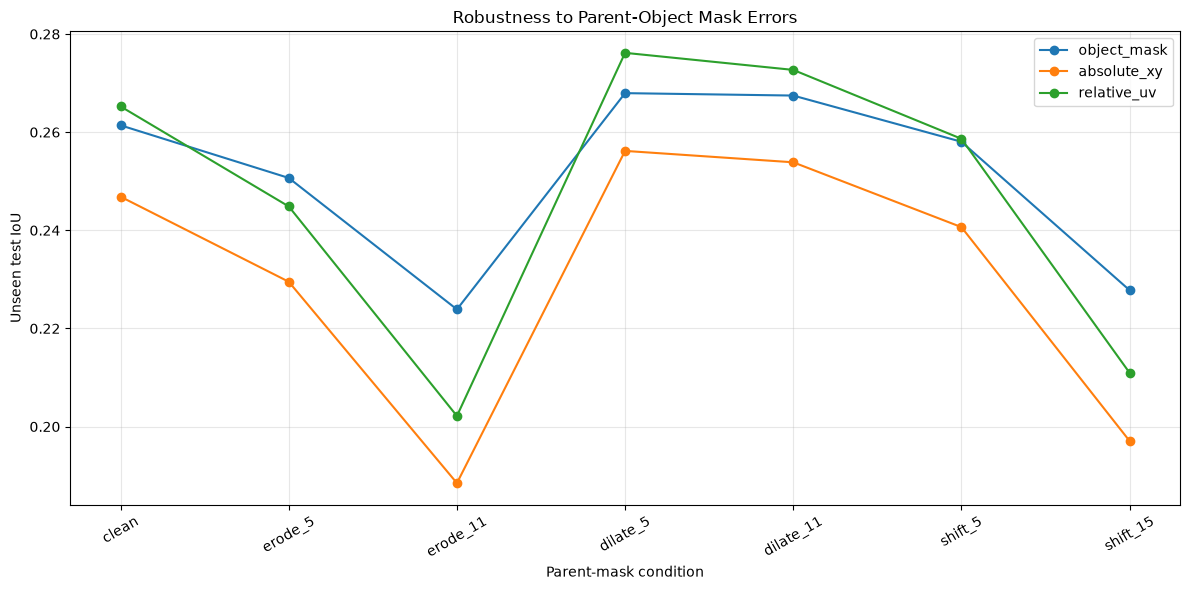

In [57]:
condition_order = (
    MASK_NOISE_CONDITIONS
)

plt.figure(
    figsize=(12, 6)
)

for model_name in MODEL_MODES:

    subset = (
        unseen_mask_results[
            unseen_mask_results[
                "model"
            ]
            == model_name
        ]
        .set_index(
            "condition"
        )
        .loc[
            condition_order
        ]
        .reset_index()
    )

    plt.plot(
        subset["condition"],
        subset["iou"],
        marker="o",
        label=model_name,
    )

plt.ylabel(
    "Unseen test IoU"
)

plt.xlabel(
    "Parent-mask condition"
)

plt.title(
    "Robustness to Parent-Object Mask Errors"
)

plt.xticks(
    rotation=30
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

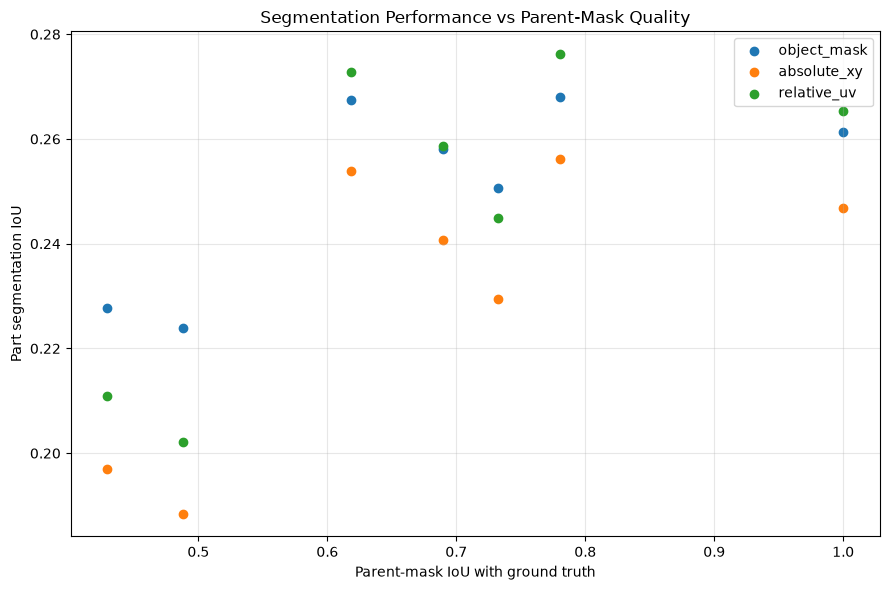

In [58]:
plt.figure(
    figsize=(9, 6)
)

for model_name in MODEL_MODES:

    subset = (
        unseen_mask_results[
            unseen_mask_results[
                "model"
            ]
            == model_name
        ]
    )

    plt.scatter(
        subset[
            "conditioning_mask_iou"
        ],
        subset["iou"],
        label=model_name,
    )

plt.xlabel(
    "Parent-mask IoU with ground truth"
)

plt.ylabel(
    "Part segmentation IoU"
)

plt.title(
    "Segmentation Performance vs Parent-Mask Quality"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [59]:
@torch.no_grad()
def predict_all_models(
    sample,
):

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    object_mask = (
        sample["object_mask"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    absolute_x = (
        sample["absolute_x"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    absolute_y = (
        sample["absolute_y"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_u = (
        sample["relative_u"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    relative_v = (
        sample["relative_v"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    text = text_encoder(
        [
            sample["query"]
        ]
    )

    shared_model = next(
        iter(models.values())
    )

    features = (
        shared_model
        .extract_dino_features(
            image
        )
    )

    predictions = {}

    for name, model in (
        models.items()
    ):

        logits = (
            model
            .forward_from_features(
                features,
                text,
                object_mask,
                absolute_x,
                absolute_y,
                relative_u,
                relative_v,
                image.shape[-2:],
            )
        )

        probability = (
            torch.sigmoid(
                logits
            )[0, 0]
            .cpu()
        )

        predictions[name] = (
            probability
            >= MASK_THRESHOLD
        )

    return predictions

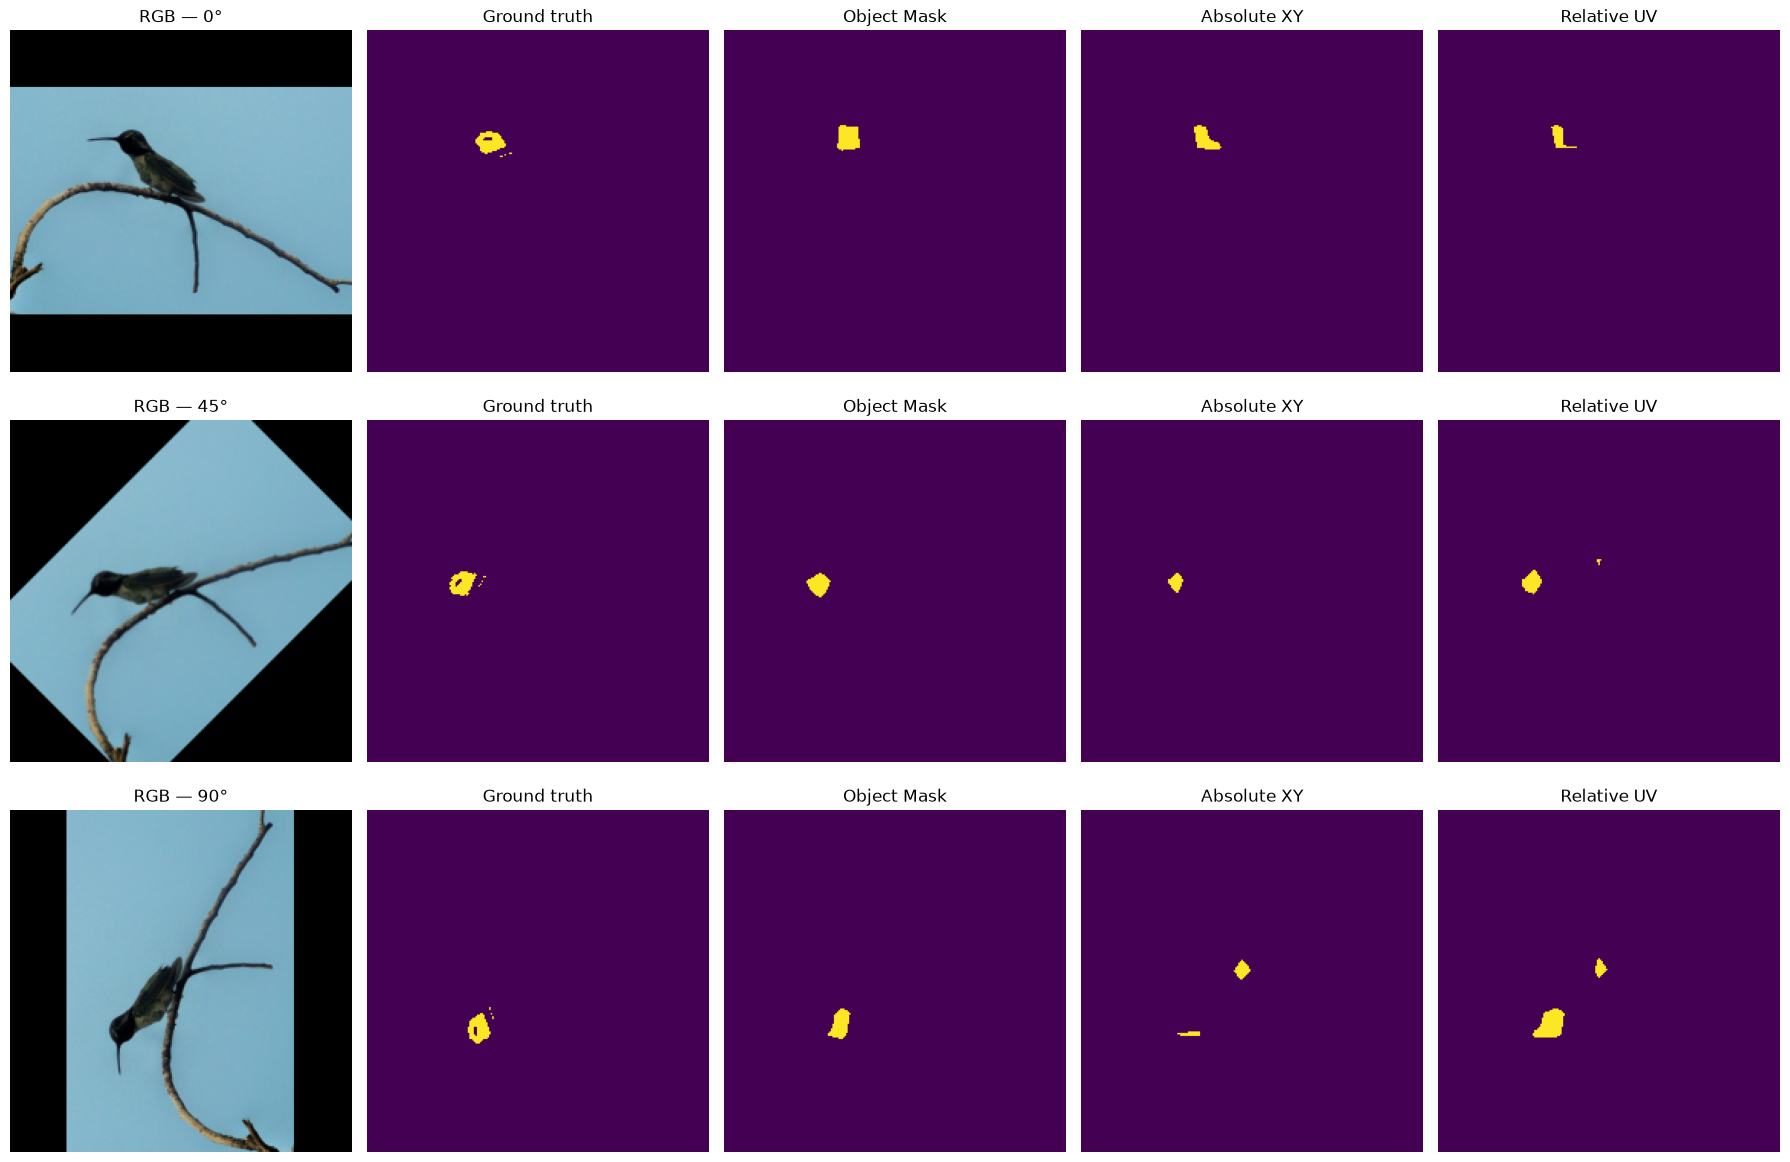

In [60]:
QUALITATIVE_INDEX = 10

angles_to_show = [
    0,
    45,
    90,
]

fig, axes = plt.subplots(
    len(angles_to_show),
    5,
    figsize=(18, 12),
)

for row, angle in enumerate(
    angles_to_show
):

    dataset = RobustnessDataset(
        split="test_unseen",
        experiment_type="rotation",
        condition=angle,
    )

    sample = dataset[
        QUALITATIVE_INDEX
    ]

    predictions = (
        predict_all_models(
            sample
        )
    )

    axes[row, 0].imshow(
        sample[
            "display_image"
        ]
        .permute(1, 2, 0)
    )

    axes[row, 0].set_title(
        f"RGB — {angle}°"
    )

    axes[row, 1].imshow(
        sample[
            "part_mask"
        ].squeeze()
    )

    axes[row, 1].set_title(
        "Ground truth"
    )

    axes[row, 2].imshow(
        predictions[
            "object_mask"
        ]
    )

    axes[row, 2].set_title(
        "Object Mask"
    )

    axes[row, 3].imshow(
        predictions[
            "absolute_xy"
        ]
    )

    axes[row, 3].set_title(
        "Absolute XY"
    )

    axes[row, 4].imshow(
        predictions[
            "relative_uv"
        ]
    )

    axes[row, 4].set_title(
        "Relative UV"
    )


for ax in axes.flat:

    ax.axis("off")


plt.tight_layout()
plt.show()

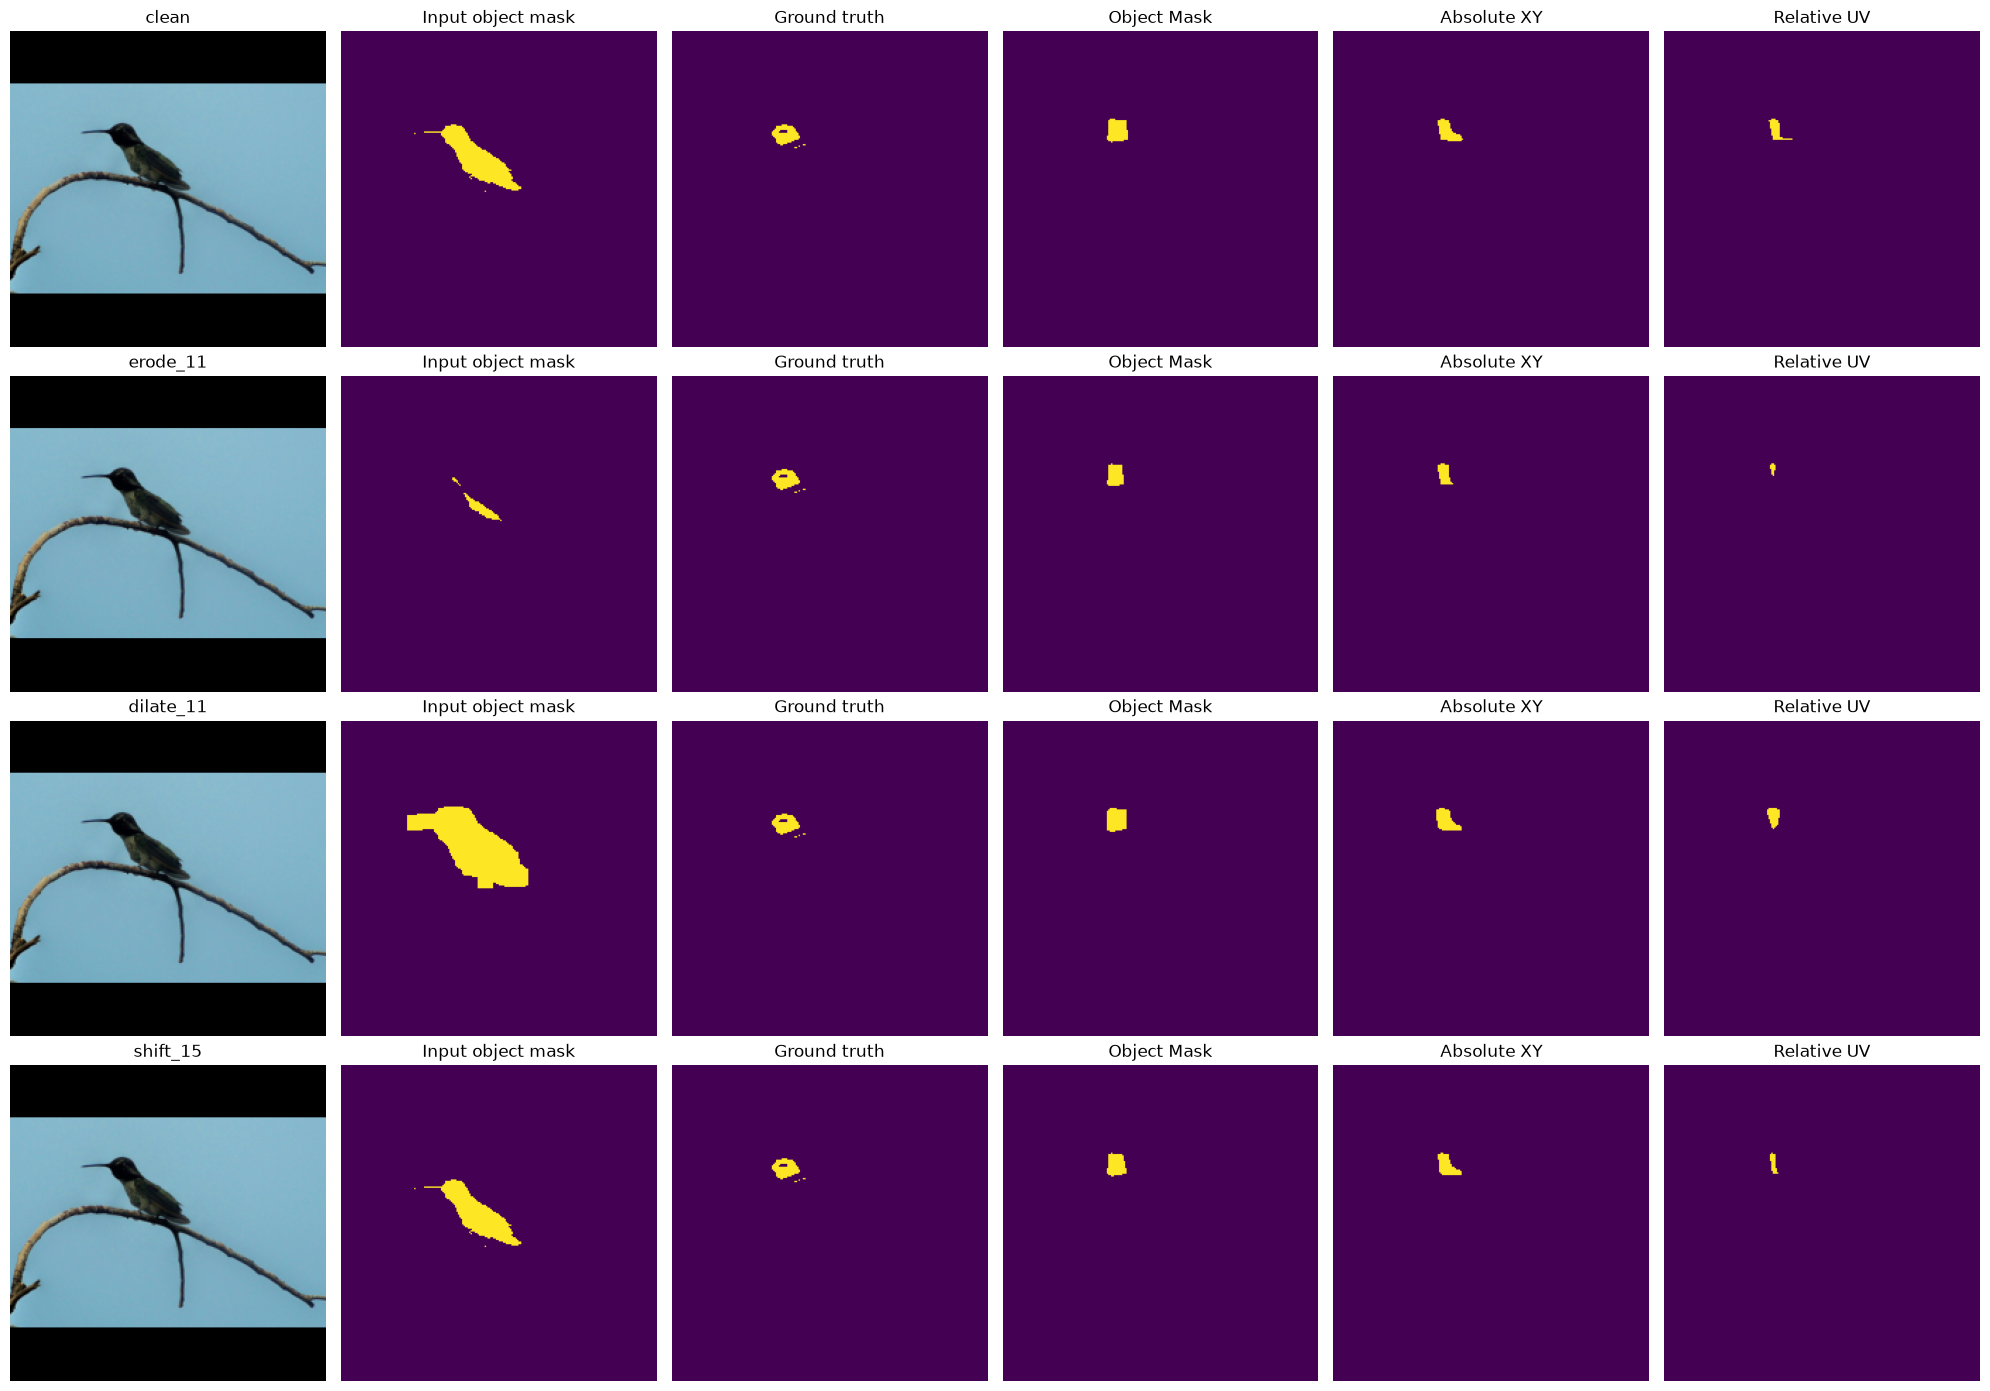

In [61]:
conditions_to_show = [
    "clean",
    "erode_11",
    "dilate_11",
    "shift_15",
]

fig, axes = plt.subplots(
    len(conditions_to_show),
    6,
    figsize=(20, 14),
)

for row, condition in enumerate(
    conditions_to_show
):

    dataset = RobustnessDataset(
        split="test_unseen",
        experiment_type="mask_noise",
        condition=condition,
    )

    sample = dataset[
        QUALITATIVE_INDEX
    ]

    predictions = (
        predict_all_models(
            sample
        )
    )


    axes[row, 0].imshow(
        sample[
            "display_image"
        ]
        .permute(1, 2, 0)
    )

    axes[row, 0].set_title(
        condition
    )


    axes[row, 1].imshow(
        sample[
            "object_mask"
        ].squeeze()
    )

    axes[row, 1].set_title(
        "Input object mask"
    )


    axes[row, 2].imshow(
        sample[
            "part_mask"
        ].squeeze()
    )

    axes[row, 2].set_title(
        "Ground truth"
    )


    axes[row, 3].imshow(
        predictions[
            "object_mask"
        ]
    )

    axes[row, 3].set_title(
        "Object Mask"
    )


    axes[row, 4].imshow(
        predictions[
            "absolute_xy"
        ]
    )

    axes[row, 4].set_title(
        "Absolute XY"
    )


    axes[row, 5].imshow(
        predictions[
            "relative_uv"
        ]
    )

    axes[row, 5].set_title(
        "Relative UV"
    )


for ax in axes.flat:

    ax.axis("off")


plt.tight_layout()
plt.show()

In [62]:
rotation_path = (
    OUTPUT_ROOT
    / "rotation_results.csv"
)

mask_path = (
    OUTPUT_ROOT
    / "mask_robustness_results.csv"
)


rotation_results.to_csv(
    rotation_path,
    index=False,
)

mask_results.to_csv(
    mask_path,
    index=False,
)


print(
    "Saved:",
    rotation_path
)

print(
    "Saved:",
    mask_path
)

Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/robustness/rotation_results.csv
Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/robustness/mask_robustness_results.csv


In [63]:
rotation_summary = (
    rotation_results[
        rotation_results[
            "split"
        ]
        == "unseen"
    ]
    .pivot(
        index="angle",
        columns="model",
        values="iou",
    )
)

rotation_summary

model,absolute_xy,object_mask,relative_uv
angle,,,
0,0.246844,0.261407,0.265242
15,0.246149,0.259403,0.261212
30,0.236279,0.246539,0.250355
45,0.225508,0.229909,0.234647
90,0.188765,0.189173,0.194835


In [64]:
mask_summary = (
    mask_results[
        mask_results[
            "split"
        ]
        == "unseen"
    ]
    .pivot(
        index="condition",
        columns="model",
        values="iou",
    )
)

mask_summary

model,absolute_xy,object_mask,relative_uv
condition,,,
clean,0.246843,0.261395,0.265243
dilate_11,0.253860,0.267462,0.272691
dilate_5,0.256181,0.267953,0.276166
erode_11,0.188475,0.223877,0.202155
erode_5,0.229513,0.250667,0.244861
shift_15,0.197073,0.227794,0.210962
shift_5,0.240652,0.258046,0.258652


In [65]:
rotation_summary.to_csv(
    OUTPUT_ROOT
    / "rotation_summary_unseen.csv"
)

mask_summary.to_csv(
    OUTPUT_ROOT
    / "mask_summary_unseen.csv"
)

# Rotation Interpretation

The most important quantity is not only absolute IoU.

We should also inspect the drop relative to the clean 0° condition.

---

## Possible Result A

Relative UV performs best at 0° but degrades faster as rotation increases.

Interpretation:

The relative coordinate system contains useful positional information under
normal object orientations, but also introduces an orientation-dependent bias.

This would directly support the concern raised in the project feedback.

---

## Possible Result B

Relative UV remains stronger than Absolute XY at all angles.

Interpretation:

The relative reference frame provides useful information even under moderate
changes in orientation.

---

## Possible Result C

All three models degrade similarly.

Interpretation:

The main rotation sensitivity may come from the visual representation or
segmentation decoder rather than from the explicit coordinate system.

---

## Possible Result D

Object Mask remains strongest under large rotations.

Interpretation:

Explicit coordinates may provide useful priors under standard data
distributions but reduce robustness under distribution shifts.

# Parent-Mask Robustness Interpretation

The parent object mask is assumed to be ground truth during normal training.

This experiment relaxes that assumption.

---

## Erosion

Parts of the true object disappear from the parent mask.

If performance drops strongly, the model depends heavily on complete
parent-object coverage.

Relative U/V can be affected twice:

1. object pixels disappear;
2. the object's bounding box and therefore the coordinate system may change.

---

## Dilation

Background pixels are incorrectly included in the object mask.

This tests whether the model can ignore irrelevant regions even when the
parent-object constraint becomes less precise.

---

## Translation

The object mask has approximately the correct shape but is spatially
misaligned.

This is particularly interesting for U/V because the coordinate reference
frame itself is moved.

---

## Main Comparison

If Relative UV degrades faster than Absolute XY as parent-mask quality falls,
then object-relative geometry is more dependent on accurate object
localization.

If the degradation is similar, relative geometry may be reasonably robust
to realistic upstream mask errors.

# Notebook 05 Summary

This notebook evaluated robustness without retraining any model.

## Rotation Robustness

The models were evaluated at:

- 0°
- 15°
- 30°
- 45°
- 90°

RGB images, object masks and ground-truth part masks were rotated jointly.

Geometry was recomputed after rotation.

This measures sensitivity to orientation changes.

---

## Parent-Mask Robustness

The models were evaluated using:

- clean masks
- erosion
- dilation
- translation

The RGB image and ground-truth part segmentation remained unchanged.

Only the parent-object mask was corrupted.

Geometry was recomputed from the corrupted mask.

This simulates errors from an upstream object-segmentation system.

---

## Models Compared

1. DINO + CLIP + Object Mask
2. DINO + CLIP + Object Mask + Absolute XY
3. DINO + CLIP + Object Mask + Relative UV

No model was retrained.

---

## Scientific Questions Answered

1. Are explicit coordinates redundant with DINOv2?
2. Does object-relative geometry introduce orientation bias?
3. How dependent is U/V on accurate parent-object masks?
4. Is relative geometry more or less robust than absolute image position?

The next notebook can now focus on improving fine-grained semantic grounding
rather than adding another coordinate representation.